## Лабораторная работа №2 Rays


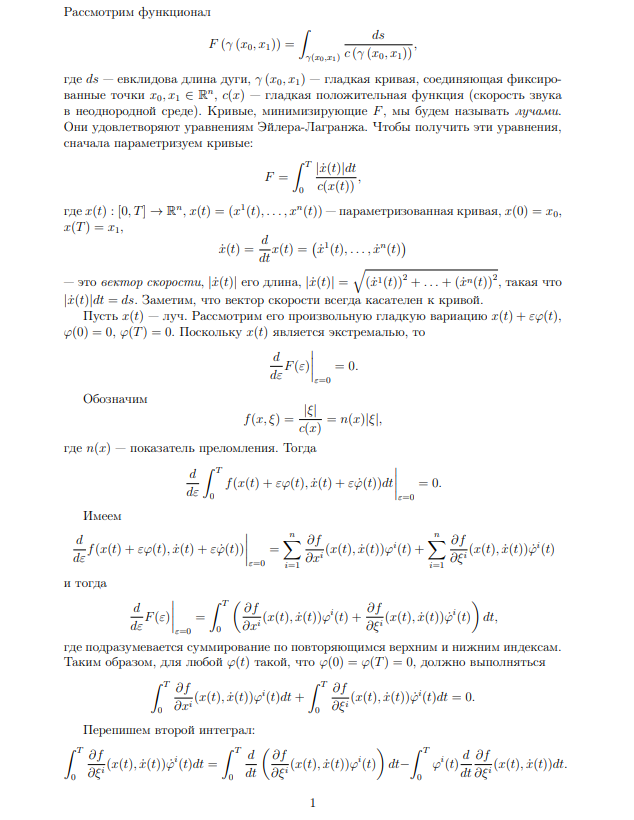

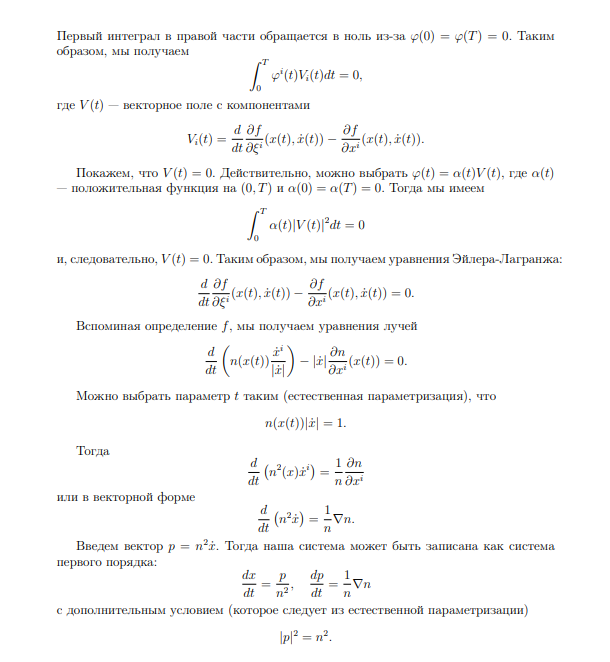
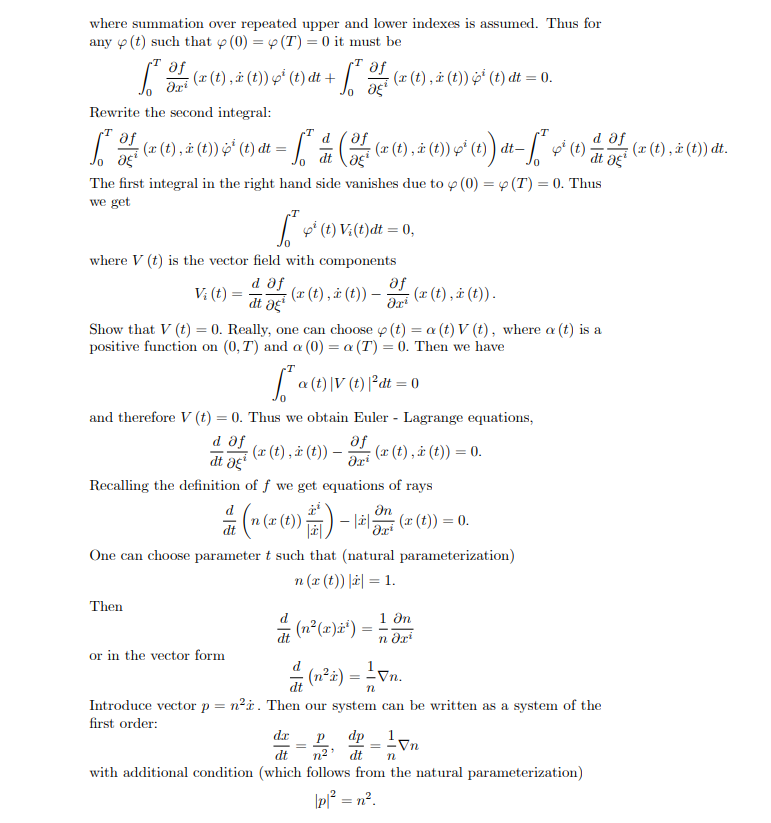
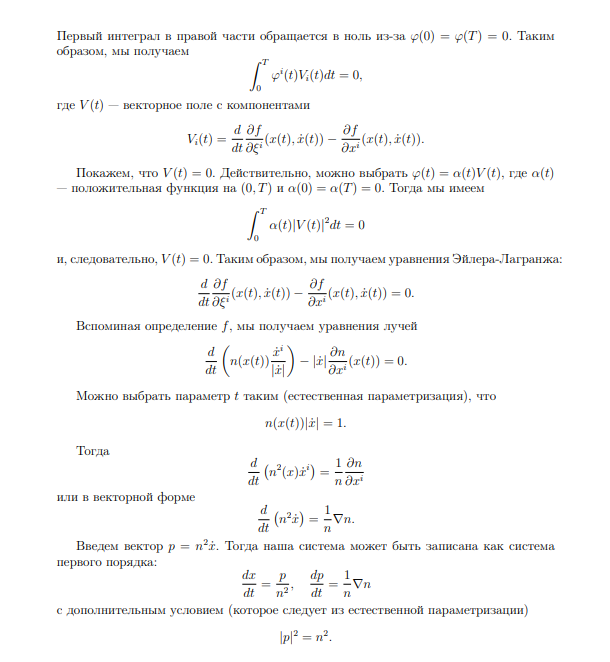

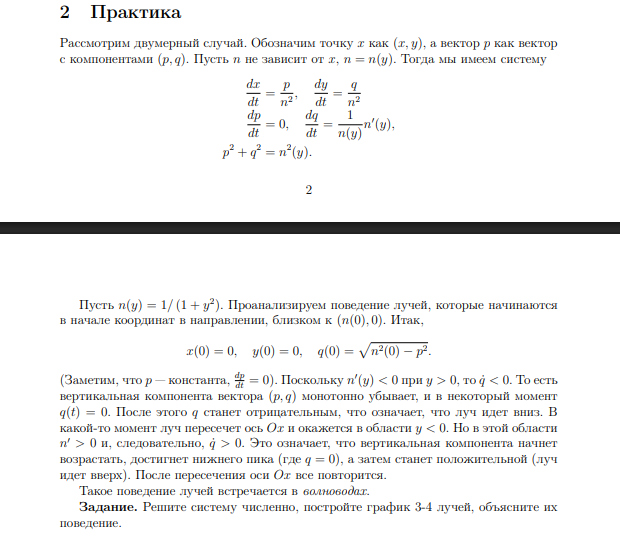

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Показатель преломления и его производная:

$$
n(y) = \frac{1}{\sqrt{1 + y^2}}, \quad
\frac{dn}{dy} = - \frac{y}{(1 + y^2)^{3/2}}
$$

In [2]:
def n(y):
    return 1.0 / np.sqrt(1 + y**2)

def dn_dy(y):
    return -y / (1 + y**2)**(3/2)

In [3]:
def ray_system(t, z, p):
    x, y, q = z
    n_val = n(y)
    dxdt = p / n_val**2
    dydt = q / n_val**2
    dqdt = dn_dy(y) / n_val
    return [dxdt, dydt, dqdt]


$$
n(y) = \frac{1}{\sqrt{1 + y^2}}
$$

показатель преломления меняется только по y.
Градиент показателя преломления:
  $$
  \frac{dn}{dy} = - \frac{y}{(1 + y^2)^{3/2}}
  $$

### 2. Система уравнений

Мы решаем систему первого порядка,

$$
\frac{dx}{dt} = \frac{p}{n^2}, \quad
\frac{dy}{dt} = \frac{q}{n^2}, \quad
\frac{dq}{dt} = \frac{1}{n} \frac{dn}{dy}
$$

### 3. Начальные условия

Для каждого луча:

$$
x(0) = 0, \quad y(0) = 0
$$

q вычисляется так, чтобы выполнялось условие:

$$
p^2 + q_0^2 = n(0)^2
$$

Коротко:
> Мы считаем, как лучи проходят через среду с n(y), решая систему ((x(t), y(t), q(t))) из первого порядка, учитывая изменение вертикального импульса из-за градиента (dn/dy).

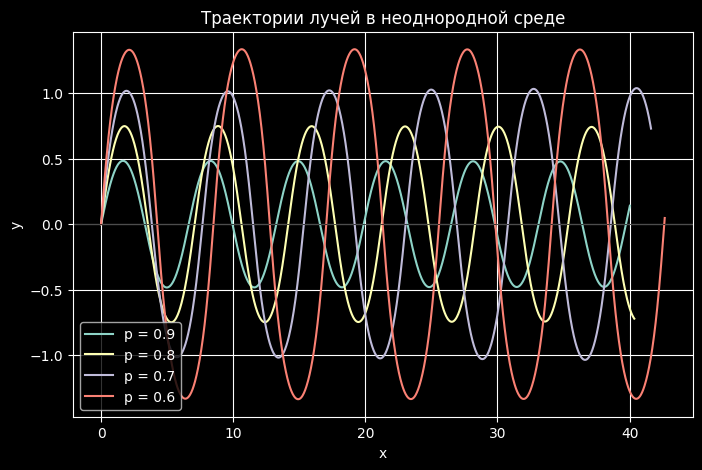

In [4]:
t_span = (0, 40)
t_eval = np.linspace(*t_span, 2000)

plt.figure(figsize=(8, 5))
for p in [0.9, 0.8, 0.7, 0.6]:
    q0 = np.sqrt(n(0)**2 - p**2)
    z0 = [0.0, 0.0, q0]
    sol = solve_ivp(ray_system, t_span, z0, t_eval=t_eval, args=(p,))
    plt.plot(sol.y[0], sol.y[1], label=f'p = {p}')

plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Траектории лучей в неоднородной среде')
plt.legend()
plt.grid(True)
plt.show()